### metadata combine

In [ ]:
import os
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/fmri_project/Patients_metadata"

cn_meta = pd.read_csv(os.path.join(DATA_DIR, "metadata_cn.csv"))   # change name
ad_meta = pd.read_csv(os.path.join(DATA_DIR, "metadata_ad.csv"))   # change name

# Make sure both have the same column names
# Example expected columns: subject, DX, MMSE

cn_meta["DX"] = "CN"
ad_meta["DX"] = "AD"

meta = pd.concat([cn_meta, ad_meta], ignore_index=True)

# keep only the columns we need
meta = meta[["subject_id", "dx", "mmse"]].copy()

# make subject format consistent
meta["subject_id"] = meta["subject_id"].astype(str).str.strip()

print(meta.head())
print(meta["dx"].value_counts())

     subject_id  dx  mmse
0  sub-002S1261  CN  30.0
1  sub-002S1280  CN  30.0
2  sub-003S4441  CN  28.0
3  sub-003S4872  CN  28.0
4  sub-003S6014  CN  30.0
dx
CN          62
Dementia    12
MCI          5
Name: count, dtype: int64


In [ ]:
base_df = pd.DataFrame({
    "subject_id": subjects.astype(str),
    "age": ages
})

base_df["subject_id"] = base_df["subject_id"].str.strip()
df = base_df.merge(meta, on="subject_id", how="left")

print(df.head())
print(df["dx"].value_counts(dropna=False))

     subject_id        age  dx  mmse
0  sub-002S1261  71.099998  CN  30.0
1  sub-002S1280  70.699997  CN  30.0
2  sub-003S4441  68.699997  CN  28.0
3  sub-003S4872  68.500000  CN  28.0
4  sub-003S6014  67.099998  CN  30.0
dx
CN     62
NaN     1
Name: count, dtype: int64


In [ ]:
missing_dx = df["dx"].isna().sum()
print("Subjects missing DX:", missing_dx)

Subjects missing DX: 1


# main code

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# import math
# import numpy as np
# import pandas as pd

# from sklearn.model_selection import LeaveOneOut, GridSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.svm import SVR
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from sklearn.metrics import make_scorer
# import numpy as np

# # --------------------------------------------------
# # 1. Paths
# # --------------------------------------------------
# DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"
# NPZ_FILE = "fmri_features_CN.npz"
# # META_FILE = df # Removed: This was incorrectly assigning a DataFrame as a file path
# OUT_DIR = "/content/drive/MyDrive/fmri_project/outputs"

# os.makedirs(OUT_DIR, exist_ok=True)

# # --------------------------------------------------
# # 2. Load connectivity features
# # --------------------------------------------------
# fmri_data = np.load(os.path.join(DATA_DIR, NPZ_FILE), allow_pickle=True)

# ages = fmri_data["ages"].astype(np.float32)
# full_vec = fmri_data["FULL"].astype(np.float32)
# ll_vec = fmri_data["LL"].astype(np.float32)
# lr_vec = fmri_data["LR"].astype(np.float32)
# rr_vec = fmri_data["RR"].astype(np.float32)
# subjects = fmri_data["subjects"]

# print("ages:", ages.shape)
# print("FULL:", full_vec.shape)
# print("LL:", ll_vec.shape)
# print("LR:", lr_vec.shape)
# print("RR:", rr_vec.shape)
# print("subjects:", subjects.shape)

# # --------------------------------------------------
# # 3. Load metadata with diagnosis / MMSE
# # --------------------------------------------------
# # Use the 'meta' DataFrame already prepared in previous cells.
# # Rename columns to match expected names in this section.
# meta = meta.rename(columns={"subject_id": "subject", "dx": "DX"})
# meta["subject"] = meta["subject"].astype(str)

# base_df = pd.DataFrame({
#     "subject": subjects.astype(str),
#     "age": ages
# })

# df = base_df.merge(meta, on="subject", how="left")

# print(df.head())
# print(df["DX"].value_counts(dropna=False))

# # --------------------------------------------------
# # 4. Feature sets
# # --------------------------------------------------
# feature_sets = {
#     "full": full_vec,
#     "left": ll_vec,
#     "right": rr_vec,
#     "inter": lr_vec
# }

# # --------------------------------------------------
# # 5. CN mask
# # --------------------------------------------------
# cn_mask = df["DX"].astype(str).str.upper().eq("CN").values

# print("Total subjects:", len(df))
# print("CN subjects:", cn_mask.sum())

# # --------------------------------------------------
# # 6. Metrics helper
# # --------------------------------------------------
# def regression_metrics(y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred)
#     rmse = math.sqrt(mean_squared_error(y_true, y_pred))
#     r2 = r2_score(y_true, y_pred)
#     r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
#     return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# # --------------------------------------------------
# # 7. Honest Stage 1 model:
# #    LOOCV on CN only
# # --------------------------------------------------
# outer_cv = LeaveOneOut()

# all_summary_rows = []
# all_cn_pred_rows = []
# all_subject_bag = df[["subject", "age", "DX"]].copy()

# def pearson_corr(y_true, y_pred):
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)

#     if len(y_true) < 2:
#         return 0.0
#     if np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
#         return 0.0

#     return np.corrcoef(y_true, y_pred)[0, 1]

# corr_scorer = make_scorer(pearson_corr, greater_is_better=True)

# for model_name, X_all in feature_sets.items():
#     print(f"\n========== {model_name.upper()} ==========")

#     X_cn = X_all[cn_mask]
#     y_cn = ages[cn_mask]
#     subj_cn = subjects[cn_mask].astype(str)

#     outer_true = []
#     outer_pred = []
#     outer_best_params = []

#     for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_cn), start=1):
#         X_train, X_test = X_cn[train_idx], X_cn[test_idx]
#         y_train, y_test = y_cn[train_idx], y_cn[test_idx]

#         # small grid to reduce overfitting risk
#         max_pca = min(X_train.shape[0] - 1, X_train.shape[1])
#         pca_grid = [5, 10, 15]
#         pca_grid = [n for n in pca_grid if n <= max_pca]
#         if len(pca_grid) == 0:
#             pca_grid = [max(1, min(5, max_pca))]

#         pipe = Pipeline([
#             ("scaler", StandardScaler()),
#             ("pca", PCA()),
#             ("svr", SVR(kernel="rbf"))
#         ])

#         param_grid = {
#             "pca__n_components": [5, 10, 15],
#             "svr__C": [0.1, 1, 10],
#             "svr__epsilon": [0.01, 0.1],
#             "svr__gamma": [0.01, 0.05, "scale"],
#         }

#         if len(param_grid["pca__n_components"]) == 0:
#            param_grid["pca__n_components"] = [max(1, min(5, max_pca))]

#         # inner CV on training CN only
#         from sklearn.model_selection import KFold
#         inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

#         search = GridSearchCV(
#             estimator=pipe,
#             param_grid=param_grid,
#             scoring=corr_scorer,
#             cv=inner_cv,
#             n_jobs=-1,
#             refit=True
#         )

#         y_train_mean = y_train.mean()
#         y_train_std = y_train.std() + 1e-6
#         y_train_z = (y_train - y_train_mean) / y_train_std

#         search.fit(X_train, y_train_z)
#         y_hat_z = search.best_estimator_.predict(X_test)[0]
#         y_hat = y_hat_z * y_train_std + y_train_mean

#         outer_true.append(y_test[0])
#         outer_pred.append(y_hat)
#         outer_best_params.append(search.best_params_)

#         if fold % 5 == 0 or fold == 1:
#             print(
#                 f"Fold {fold:02d} | "
#                 f"true={y_test[0]:.1f} pred={y_hat:.1f} | "
#                 f"best={search.best_params_}"
#             )

#     outer_true = np.array(outer_true)
#     outer_pred = np.array(outer_pred)

#     metrics = regression_metrics(outer_true, outer_pred)
#     print("CN LOOCV metrics:", metrics)

#     all_summary_rows.append({
#         "model": model_name,
#         **metrics
#     })

#     cn_pred_df = pd.DataFrame({
#         "model": model_name,
#         "subject": subj_cn,
#         "true_age": outer_true,
#         "pred_age": outer_pred,
#         "BAG": outer_pred - outer_true
#     })
#     all_cn_pred_rows.append(cn_pred_df)

#     # --------------------------------------------------
#     # 8. Refit final model on ALL CN, then predict ALL subjects
#     # --------------------------------------------------
#     max_pca_full = min(X_cn.shape[0] - 1, X_cn.shape[1])
#     pca_grid_full = [5, 10, 15]
#     pca_grid_full = [n for n in pca_grid_full if n <= max_pca_full]
#     if len(pca_grid_full) == 0:
#         pca_grid_full = [max(1, min(5, max_pca_full))]

#     final_pipe = Pipeline([
#         ("scaler", StandardScaler()),
#         ("pca", PCA()),
#         ("svr", SVR(kernel="rbf"))
#     ])

#     final_param_grid = {
#         "pca__n_components": pca_grid_full,
#         "svr__C": [0.1, 1, 10],
#         "svr__epsilon": [0.1, 0.5, 1.0],
#         "svr__gamma": ["scale", 0.01, 0.1],
#     }

#     final_search = GridSearchCV(
#         estimator=final_pipe,
#         param_grid=final_param_grid,
#         scoring=corr_scorer,
#         cv=KFold(n_splits=5, shuffle=True, random_state=42),
#         n_jobs=-1,
#         refit=True
#     )

#     y_cn_mean = y_cn.mean()
#     y_cn_std = y_cn.std() + 1e-6
#     y_cn_z = (y_cn - y_cn_mean) / y_cn_std

#     final_search.fit(X_cn, y_cn_z)
#     final_model = final_search.best_estimator_

#     pred_all_z = final_model.predict(X_all)
#     pred_all = pred_all_z * y_cn_std + y_cn_mean
#     all_subject_bag[f"pred_age_{model_name}"] = pred_all
#     all_subject_bag[f"BAG_{model_name}"] = pred_all - all_subject_bag["age"]

#     print("Final chosen params on all CN:", final_search.best_params_)

# # --------------------------------------------------
# # 9. Save outputs
# # --------------------------------------------------
# summary_df = pd.DataFrame(all_summary_rows)
# cn_preds_df = pd.concat(all_cn_pred_rows, ignore_index=True)

# summary_path = os.path.join(OUT_DIR, "stage1_cn_loocv_summary.csv")
# cn_preds_path = os.path.join(OUT_DIR, "stage1_cn_loocv_predictions.csv")
# bag_path = os.path.join(OUT_DIR, "stage1_all_subjects_bag.csv")

# summary_df.to_csv(summary_path, index=False)
# cn_preds_df.to_csv(cn_preds_path, index=False)
# all_subject_bag.to_csv(bag_path, index=False)

# print("\nSaved:")
# print(summary_path)
# print(cn_preds_path)
# print(bag_path)

# print("\nStage 1 summary:")
# print(summary_df)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"
NPZ_FILE = "fmri_features_CN.npz"
OUT_DIR = "/content/drive/MyDrive/fmri_project/outputs"

os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------------------------------
# 2. Load connectivity features
# --------------------------------------------------
fmri_data = np.load(os.path.join(DATA_DIR, NPZ_FILE), allow_pickle=True)

ages = fmri_data["ages"].astype(np.float32)
full_vec = fmri_data["FULL"].astype(np.float32)
ll_vec = fmri_data["LL"].astype(np.float32)
lr_vec = fmri_data["LR"].astype(np.float32)
rr_vec = fmri_data["RR"].astype(np.float32)
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("LL:", ll_vec.shape)
print("LR:", lr_vec.shape)
print("RR:", rr_vec.shape)
print("subjects:", subjects.shape)

# --------------------------------------------------
# 3. Load metadata with diagnosis / MMSE
# --------------------------------------------------
# The global 'meta' DataFrame from cell 9AV8IGMpc5el (with 'subject_id', 'dx', 'mmse')
# should be used for merging, not the global 'df' which may contain redundant columns.
# Create a local 'current_meta' DataFrame for this cell's operations.
global_meta_df = globals().get('meta', pd.DataFrame()) # Get global 'meta' if exists

if global_meta_df.empty:
    raise ValueError("The 'meta' DataFrame from previous cells (cell 9AV8IGMpc5el) is not available.")

# Explicitly select only the expected metadata columns from the global 'meta' DataFrame.
# This step is crucial to prevent duplicate columns like 'age_x', 'age_y'
# from being carried into the merge if the global 'meta' was modified elsewhere.
# Based on the kernel state, 'subject', 'DX', 'mmse' are available in the global 'meta'.
selected_meta_cols = []
if "subject" in global_meta_df.columns:
    selected_meta_cols.append("subject")
elif "subject_id" in global_meta_df.columns: # Fallback if not yet renamed
    selected_meta_cols.append("subject_id")

if "DX" in global_meta_df.columns:
    selected_meta_cols.append("DX")
elif "dx" in global_meta_df.columns: # Fallback if not yet renamed
    selected_meta_cols.append("dx")

if "mmse" in global_meta_df.columns:
    selected_meta_cols.append("mmse")

if not selected_meta_cols:
    raise ValueError("Expected metadata columns ('subject'/'subject_id', 'DX'/'dx', 'mmse') not found in the global 'meta' DataFrame.")

current_meta = global_meta_df[selected_meta_cols].copy()

# Ensure consistent naming for merge key ('subject') and diagnosis ('DX') column.
# These renames should happen *after* selecting the relevant columns.
current_meta = current_meta.rename(columns={"subject_id": "subject", "dx": "DX"})
current_meta["subject"] = current_meta["subject"].astype(str)

# Create a base DataFrame from the subjects and ages loaded in this cell.
base_df_for_merge = pd.DataFrame({
    "subject": subjects.astype(str),
    "age": ages
})

# Perform the merge. 'current_meta' now only contains 'subject', 'DX', 'mmse'.
# 'base_df_for_merge' contains 'subject', 'age'.
# The merge should now work without creating duplicate 'age' columns.
df = base_df_for_merge.merge(current_meta, on="subject", how="left")

print(df.head())
print(df["DX"].value_counts(dropna=False))

# --------------------------------------------------
# 4. Feature sets
# --------------------------------------------------
feature_sets = {
    "full": full_vec,
    "left": ll_vec,
    "right": rr_vec,
    "inter": lr_vec
}

# --------------------------------------------------
# 5. CN mask
# --------------------------------------------------
cn_mask = df["DX"].astype(str).str.upper().eq("CN").values

print("Total subjects:", len(df))
print("CN subjects:", cn_mask.sum())

# --------------------------------------------------
# 6. Metrics helper
# --------------------------------------------------
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# --------------------------------------------------
# 7. Honest Stage 1 model:
#    LOOCV on CN only
# --------------------------------------------------
outer_cv = LeaveOneOut()

all_summary_rows = []
all_cn_pred_rows = []
# Corrected column names to match the DataFrame 'df' and include 'mmse'
all_subject_bag = df[["subject", "age", "DX", "mmse"]].copy()

for model_name, X_all in feature_sets.items():
    print(f"\n========== {model_name.upper()} ==========")

    X_cn = X_all[cn_mask]
    y_cn = ages[cn_mask]
    subj_cn = subjects[cn_mask].astype(str)

    outer_true = []
    outer_pred = []
    outer_best_params = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_cn), start=1):
        X_train, X_test = X_cn[train_idx], X_cn[test_idx]
        y_train, y_test = y_cn[train_idx], y_cn[test_idx]

        # small grid to reduce overfitting risk
        max_pca = min(X_train.shape[0] - 1, X_train.shape[1])
        pca_grid = [5, 10, 15]
        pca_grid = [n for n in pca_grid if n <= max_pca]
        if len(pca_grid) == 0:
            pca_grid = [max(1, min(5, max_pca))]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("svr", SVR(kernel="rbf"))
        ])

        param_grid = {
            "pca__n_components": pca_grid,
            "svr__C": [0.1, 1, 10],
            "svr__epsilon": [0.1, 0.5, 1.0],
            "svr__gamma": ["scale", 0.01, 0.1],
        }

        # inner CV on training CN only
        inner_cv = LeaveOneOut() if len(train_idx) <= 25 else 5

        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )

        search.fit(X_train, y_train)
        y_hat = search.best_estimator_.predict(X_test)[0]

        outer_true.append(y_test[0])
        outer_pred.append(y_hat)
        outer_best_params.append(search.best_params_)

        if fold % 5 == 0 or fold == 1:
            print(
                f"Fold {fold:02d} | "
                f"true={y_test[0]:.1f} pred={y_hat:.1f} | "
                f"best={search.best_params_}"
            )

    outer_true = np.array(outer_true)
    outer_pred = np.array(outer_pred)

    metrics = regression_metrics(outer_true, outer_pred)
    print("CN LOOCV metrics:", metrics)

    all_summary_rows.append({
        "model": model_name,
        **metrics
    })

    cn_pred_df = pd.DataFrame({
        "model": model_name,
        "subject": subj_cn,
        "true_age": outer_true,
        "pred_age": outer_pred,
        "BAG": outer_pred - outer_true
    })
    all_cn_pred_rows.append(cn_pred_df)

    # --------------------------------------------------
    # 8. Refit final model on ALL CN, then predict ALL subjects
    # --------------------------------------------------
    max_pca_full = min(X_cn.shape[0] - 1, X_cn.shape[1])
    pca_grid_full = [5, 10, 15]
    pca_grid_full = [n for n in pca_grid_full if n <= max_pca_full]
    if len(pca_grid_full) == 0:
        pca_grid_full = [max(1, min(5, max_pca_full))]

    final_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("svr", SVR(kernel="rbf"))
    ])

    final_param_grid = {
        "pca__n_components": pca_grid_full,
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.1, 0.5, 1.0],
        "svr__gamma": ["scale", 0.01, 0.1],
    }

    final_search = GridSearchCV(
        estimator=final_pipe,
        param_grid=final_param_grid,
        scoring="neg_mean_absolute_error",
        cv=LeaveOneOut() if len(y_cn) <= 25 else 5,
        n_jobs=-1,
        refit=True
    )

    final_search.fit(X_cn, y_cn)
    final_model = final_search.best_estimator_

    pred_all = final_model.predict(X_all)
    all_subject_bag[f"pred_age_{model_name}"] = pred_all
    all_subject_bag[f"BAG_{model_name}"] = pred_all - all_subject_bag["age"]

    print("Final chosen params on all CN:", final_search.best_params_)

# --------------------------------------------------
# 9. Save outputs
# --------------------------------------------------
summary_df = pd.DataFrame(all_summary_rows)
cn_preds_df = pd.concat(all_cn_pred_rows, ignore_index=True)

summary_path = os.path.join(OUT_DIR, "stage1_cn_loocv_summary.csv")
cn_preds_path = os.path.join(OUT_DIR, "stage1_cn_loocv_predictions.csv")
bag_path = os.path.join(OUT_DIR, "stage1_all_subjects_bag.csv")

summary_df.to_csv(summary_path, index=False)
cn_preds_df.to_csv(cn_preds_path, index=False)
all_subject_bag.to_csv(bag_path, index=False)

print("\nSaved:")
print(summary_path)
print(cn_preds_path)
print(bag_path)

print("\nStage 1 summary:")
print(summary_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ages: (63,)
FULL: (63, 7140)
LL: (63, 1540)
LR: (63, 3136)
RR: (63, 1540)
subjects: (63,)
        subject        age  DX  mmse
0  sub-002S1261  71.099998  CN  30.0
1  sub-002S1280  70.699997  CN  30.0
2  sub-003S4441  68.699997  CN  28.0
3  sub-003S4872  68.500000  CN  28.0
4  sub-003S6014  67.099998  CN  30.0
DX
CN     62
NaN     1
Name: count, dtype: int64
Total subjects: 63
CN subjects: 62

========== FULL ==========
Fold 01 | true=71.1 pred=71.1 | best={'pca__n_components': 5, 'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
Fold 05 | true=67.1 pred=71.9 | best={'pca__n_components': 5, 'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
Fold 10 | true=70.2 pred=71.9 | best={'pca__n_components': 5, 'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
Fold 15 | true=66.1 pred=71.7 | best={'pca__n_components': 5, 'svr__C': 1, 'svr__epsilon': 0.1, 'sv

### Bag Analysis

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway, pearsonr, wilcoxon

DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"
bag_path = os.path.join(DATA_DIR, "stage1_all_subjects_bag.csv")

df = pd.read_csv(bag_path)
print(df.head())
print(df["DX"].value_counts(dropna=False))

# Keep only rows with diagnosis
df = df.dropna(subset=["DX"]).copy()
df["DX"] = df["DX"].astype(str).str.upper()

bag_cols = ["BAG_full", "BAG_left", "BAG_right", "BAG_inter"]

# -----------------------------
# 1. Group comparison: CN vs AD
# -----------------------------
group_rows = []

for col in bag_cols:
    cn = df.loc[df["DX"] == "CN", col].dropna().values
    ad = df.loc[df["DX"] == "AD", col].dropna().values

    if len(cn) > 1 and len(ad) > 1:
        t_stat, p_val = ttest_ind(cn, ad, equal_var=False)
        group_rows.append({
            "metric": col,
            "CN_mean": cn.mean(),
            "AD_mean": ad.mean(),
            "CN_std": cn.std(ddof=1),
            "AD_std": ad.std(ddof=1),
            "t_stat": t_stat,
            "p_value": p_val
        })

group_df = pd.DataFrame(group_rows)
print("\nGroup comparison")
print(group_df)

group_df.to_csv(os.path.join(DATA_DIR, "stage2_group_comparison.csv"), index=False)

# Boxplots
plt.figure(figsize=(10, 6))
plot_df = df.melt(id_vars=["subject", "DX"], value_vars=bag_cols,
                  var_name="BAG_type", value_name="BAG")
sns.boxplot(data=plot_df, x="BAG_type", y="BAG", hue="DX")
plt.title("BAG by Diagnosis Group")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Hemispheric comparison
# -----------------------------
hemi_cols = ["BAG_left", "BAG_right", "BAG_inter"]

hemi_long = df.melt(
    id_vars=["subject", "DX"],
    value_vars=hemi_cols,
    var_name="hemisphere_type",
    value_name="BAG"
)

# overall means
hemi_summary = hemi_long.groupby("hemisphere_type")["BAG"].agg(["mean", "std", "count"]).reset_index()
print("\nHemispheric summary")
print(hemi_summary)
hemi_summary.to_csv(os.path.join(DATA_DIR, "stage2_hemispheric_summary.csv"), index=False)

# paired within-subject comparisons
left_vals = df["BAG_left"].values
right_vals = df["BAG_right"].values
inter_vals = df["BAG_inter"].values

pair_rows = []

for name_a, a, name_b, b in [
    ("BAG_left", left_vals, "BAG_right", right_vals),
    ("BAG_left", left_vals, "BAG_inter", inter_vals),
    ("BAG_right", right_vals, "BAG_inter", inter_vals),
]:
    mask = ~np.isnan(a) & ~np.isnan(b)
    if mask.sum() > 1:
        stat, p = wilcoxon(a[mask], b[mask])
        pair_rows.append({
            "comparison": f"{name_a} vs {name_b}",
            "mean_a": np.mean(a[mask]),
            "mean_b": np.mean(b[mask]),
            "wilcoxon_stat": stat,
            "p_value": p
        })

pair_df = pd.DataFrame(pair_rows)
print("\nPaired hemispheric comparison")
print(pair_df)
pair_df.to_csv(os.path.join(DATA_DIR, "stage2_hemispheric_paired_tests.csv"), index=False)

plt.figure(figsize=(8, 6))
sns.boxplot(data=hemi_long, x="hemisphere_type", y="BAG")
sns.stripplot(data=hemi_long, x="hemisphere_type", y="BAG", color="black", alpha=0.35)
plt.title("Hemispheric BAG Comparison")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. MMSE correlation
# -----------------------------
mmse_rows = []

for col in bag_cols:
    sub = df.dropna(subset=[col, "mmse"]).copy()
    if len(sub) > 2:
        r, p = pearsonr(sub[col], sub["mmse"])
        mmse_rows.append({
            "metric": col,
            "n": len(sub),
            "pearson_r": r,
            "p_value": p
        })

        plt.figure(figsize=(5, 4))
        sns.regplot(data=sub, x=col, y="mmse", scatter_kws={"alpha": 0.8})
        plt.title(f"MMSE vs {col}\nr={r:.2f}, p={p:.3g}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

mmse_df = pd.DataFrame(mmse_rows)
print("\nMMSE correlations")
print(mmse_df)
mmse_df.to_csv(os.path.join(DATA_DIR, "stage2_mmse_correlations.csv"), index=False)

### SVM

In [ ]:
# """
# svm_classification.py
# =====================
# SVM-based CN vs. AD classifier using rs-fMRI connectivity features.

# Root-cause fixes applied vs. the old version
# ---------------------------------------------
# 1. DEAD CODE (AD_extracted CSVs): the `additional_data` block scanned
#    AD_extracted for .csv files — that folder contains only .nii.gz/.tsv
#    files.  It added nothing but silently swelled bag_df with NaN columns,
#    corrupting the label vector.

# 2. WRONG INPUT — BAG as features: the old code used four BAG scalars
#    (brain-age gap) as the sole features for the SVM.  With only 19
#    subjects and an already-under-powered SVR, the BAG signal was weak
#    and *inverted* for most AD subjects (mean BAG_full = −5.6 years,
#    i.e. the SVR thought AD brains looked YOUNGER, not older).  Feeding
#    four noisy scalars into an SVM on 19 samples is worse than random.

# 3. TINY HOLDOUT / DATA-LEAKAGE: 70/30 train-test split → 6-sample test
#    set.  GridSearchCV with 5-fold CV on 13 samples is statistically
#    meaningless.  SMOTE on 3 AD training samples with k=2 manufactures
#    fake data that bloats the majority class while doing nothing useful.

# 4. GLOBAL FEATURE SELECTION LEAK: the "improved" version achieved 100%
#    accuracy by selecting features on the entire dataset, then testing on
#    a subset — classic leakage.

# FIX: Leave-One-Out CV directly on the raw 6 670-dimensional upper-
# triangle connectivity vectors, with *all* preprocessing (Mann-Whitney
# feature selection, StandardScaler, PCA) strictly inside each fold.
# This gives honest held-out metrics across every one of the 19 subjects.
# """

# import os
# import warnings
# import numpy as np
# import pandas as pd
# import matplotlib
# matplotlib.use("Agg")
# import matplotlib.pyplot as plt

# from scipy.stats import mannwhitneyu
# from sklearn.decomposition import PCA
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     roc_auc_score,
#     roc_curve,
#     auc,
#     balanced_accuracy_score,
#     ConfusionMatrixDisplay,
# )
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC

# warnings.filterwarnings("ignore")

# # ──────────────────────────────────────────────────────────────────────
# # 1.  Paths
# # ──────────────────────────────────────────────────────────────────────
# BASE_DIR =  "/content/drive/MyDrive/fmri_project/outputs"
# DATA_DIR = os.path.join(BASE_DIR, "SVM", "outputs")
# OUT_DIR  = DATA_DIR
# os.makedirs(OUT_DIR, exist_ok=True)

# # ──────────────────────────────────────────────────────────────────────
# # 2.  Load raw connectivity features
# # ──────────────────────────────────────────────────────────────────────
# cn_path = os.path.join(DATA_DIR, "fmri_CN_features.npz")
# ad_path = os.path.join(DATA_DIR, "fmri_AD_features.npz")

# for p in (cn_path, ad_path):
#     if not os.path.exists(p):
#         raise FileNotFoundError(f"Missing: {p}\nRun svrmodel1.py first.")

# fmri_cn = np.load(cn_path, allow_pickle=True)
# fmri_ad = np.load(ad_path, allow_pickle=True)

# # ------------------------------------------------------------------
# # Feature sets available: FULL, LL (left), RR (right), LR (inter)
# # We use FULL (whole-brain upper-triangle) as the primary feature set.
# # Each row is one subject; each column is one edge in the FC matrix.
# # ------------------------------------------------------------------
# cn_full = fmri_cn["FULL"].astype(np.float32)   # (14, 6670)
# ad_full = fmri_ad["FULL"].astype(np.float32)   #  (5, 6670)

# X = np.vstack([cn_full, ad_full])              # (19, 6670)
# y = np.array([0] * len(cn_full) + [1] * len(ad_full), dtype=int)  # CN=0, AD=1

# subjects = np.concatenate([fmri_cn["subjects"].astype(str),
#                            fmri_ad["subjects"].astype(str)])
# ages     = np.concatenate([fmri_cn["ages"].astype(np.float32),
#                            fmri_ad["ages"].astype(np.float32)])
# dx_labels = ["CN"] * len(cn_full) + ["AD"] * len(ad_full)

# print("=" * 60)
# print("SVM Classification: CN vs. AD")
# print("=" * 60)
# print(f"Total subjects : {len(y)}  (CN={( y==0).sum()}, AD={(y==1).sum()})")
# print(f"Feature vector : {X.shape[1]}-dim (FULL upper-triangle FC)")
# print()

# # ──────────────────────────────────────────────────────────────────────
# # 3.  Leave-One-Out CV  (honest, no leakage)
# #
# #     Inside every fold:
# #       a) Mann-Whitney U on training subjects only → select p < 0.05
# #       b) StandardScaler fit on training subjects only
# #       c) PCA (n_components = min(5, n_train-1))
# #       d) SVC(kernel='rbf', C=10, gamma='scale')
# # ──────────────────────────────────────────────────────────────────────
# y_true_list  = []
# y_pred_list  = []
# y_prob_list  = []
# n_feat_list  = []

# print("Running Leave-One-Out CV …")
# for test_idx in range(len(y)):
#     train_idx = np.array([i for i in range(len(y)) if i != test_idx])

#     X_tr = X[train_idx]
#     X_te = X[test_idx : test_idx + 1]
#     y_tr = y[train_idx]

#     # --- a) Feature selection (Mann-Whitney, training set only) ------
#     cn_tr = X_tr[y_tr == 0]
#     ad_tr = X_tr[y_tr == 1]

#     pvals = np.array([
#         mannwhitneyu(cn_tr[:, j], ad_tr[:, j], alternative="two-sided").pvalue
#         for j in range(X_tr.shape[1])
#     ])
#     mask = pvals < 0.05
#     if mask.sum() < 10:           # fall back to top-50 if threshold too strict
#         mask = np.zeros(X_tr.shape[1], dtype=bool)
#         mask[np.argsort(pvals)[:50]] = True

#     X_tr_sel = X_tr[:, mask]
#     X_te_sel = X_te[:, mask]
#     n_feat_list.append(mask.sum())

#     # --- b) Scaling --------------------------------------------------
#     scaler  = StandardScaler()
#     X_tr_sc = scaler.fit_transform(X_tr_sel)
#     X_te_sc = scaler.transform(X_te_sel)

#     # --- c) PCA ------------------------------------------------------
#     n_comp  = min(5, X_tr_sc.shape[0] - 1, X_tr_sc.shape[1])
#     pca     = PCA(n_components=n_comp, random_state=42)
#     X_tr_pc = pca.fit_transform(X_tr_sc)
#     X_te_pc = pca.transform(X_te_sc)

#     # --- d) SVC ------------------------------------------------------
#     clf = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
#     clf.fit(X_tr_pc, y_tr)

#     pred = clf.predict(X_te_pc)[0]
#     prob = clf.predict_proba(X_te_pc)[0, 1]   # P(AD)

#     y_true_list.append(y[test_idx])
#     y_pred_list.append(pred)
#     y_prob_list.append(prob)

#     status = "✓" if pred == y[test_idx] else "✗"
#     print(
#         f"  [{status}] {subjects[test_idx]:20s} | true={dx_labels[test_idx]:2s} "
#         f"pred={'AD' if pred else 'CN':2s} | P(AD)={prob:.3f} | feats={mask.sum()}"
#     )

# y_true = np.array(y_true_list)
# y_pred = np.array(y_pred_list)
# y_prob = np.array(y_prob_list)

# # ──────────────────────────────────────────────────────────────────────
# # 4.  Metrics
# # ──────────────────────────────────────────────────────────────────────
# print("\n" + "=" * 60)
# print("LOOCV Classification Report")
# print("=" * 60)
# report = classification_report(y_true, y_pred, target_names=["CN", "AD"], digits=4)
# print(report)

# cm   = confusion_matrix(y_true, y_pred)
# bacc = balanced_accuracy_score(y_true, y_pred)
# roc_auc_val = roc_auc_score(y_true, y_prob)

# print(f"Confusion Matrix:\n{cm}")
# print(f"\nBalanced Accuracy : {bacc:.4f}")
# print(f"ROC-AUC           : {roc_auc_val:.4f}")
# print(f"Avg # features/fold : {np.mean(n_feat_list):.0f}")

# # ──────────────────────────────────────────────────────────────────────
# # 5.  Per-subject report card (BAG + classification result)
# # ──────────────────────────────────────────────────────────────────────
# bag_path = os.path.join(DATA_DIR, "stage1_all_subjects_bag.csv")
# bag_df   = pd.read_csv(bag_path)

# report_df = pd.DataFrame({
#     "subject"  : subjects,
#     "age"      : ages,
#     "DX_true"  : dx_labels,
#     "DX_pred"  : ["AD" if p else "CN" for p in y_pred],
#     "P_AD"     : y_prob.round(4),
#     "correct"  : (y_true == y_pred),
# })
# report_df = report_df.merge(
#     bag_df[["subject", "BAG_full", "BAG_left", "BAG_right", "BAG_inter"]],
#     on="subject", how="left"
# )
# print("\nPer-subject report card:")
# print(report_df.to_string(index=False))

# # ──────────────────────────────────────────────────────────────────────
# # 6.  Plots
# # ──────────────────────────────────────────────────────────────────────
# # -- ROC curve --------------------------------------------------------
# fpr, tpr, _ = roc_curve(y_true, y_prob)
# roc_auc_plot = auc(fpr, tpr)

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# fig.suptitle("SVM CN vs. AD Classification (LOOCV)", fontsize=14, fontweight="bold")

# ax_roc = axes[0]
# ax_roc.plot(fpr, tpr, color="darkorange", lw=2.5,
#             label=f"ROC (AUC = {roc_auc_plot:.3f})")
# ax_roc.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Chance")
# ax_roc.set_xlabel("False Positive Rate", fontsize=11)
# ax_roc.set_ylabel("True Positive Rate", fontsize=11)
# ax_roc.set_title("ROC Curve (LOOCV)", fontsize=12)
# ax_roc.legend(loc="lower right", fontsize=10)
# ax_roc.set_xlim([-0.02, 1.02])
# ax_roc.set_ylim([-0.02, 1.05])

# # -- Confusion matrix -------------------------------------------------
# ax_cm = axes[1]
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["CN", "AD"])
# disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
# ax_cm.set_title(f"Confusion Matrix\n(Balanced Acc = {bacc:.3f})", fontsize=12)

# plt.tight_layout()
# fig_path = os.path.join(OUT_DIR, "svm_loocv_results.png")
# plt.savefig(fig_path, dpi=150, bbox_inches="tight")
# plt.close()
# print(f"\nSaved combined figure → {fig_path}")

# # -- P(AD) per subject ------------------------------------------------
# fig2, ax2 = plt.subplots(figsize=(11, 4))
# colors = ["#e74c3c" if dx == "AD" else "#2980b9" for dx in dx_labels]
# bars = ax2.bar(subjects, y_prob, color=colors, edgecolor="white", linewidth=0.6)
# ax2.axhline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision boundary")
# ax2.set_xlabel("Subject", fontsize=10)
# ax2.set_ylabel("P(AD)", fontsize=11)
# ax2.set_title("LOOCV: Predicted P(AD) per subject\n(red=AD, blue=CN)", fontsize=12)
# ax2.set_ylim(0, 1)
# ax2.tick_params(axis="x", rotation=65, labelsize=7)
# ax2.legend(fontsize=9)
# plt.tight_layout()
# prob_fig_path = os.path.join(OUT_DIR, "svm_loocv_prob_per_subject.png")
# plt.savefig(prob_fig_path, dpi=150, bbox_inches="tight")
# plt.close()
# print(f"Saved probability plot → {prob_fig_path}")

# # ──────────────────────────────────────────────────────────────────────
# # 7.  Save outputs
# # ──────────────────────────────────────────────────────────────────────
# report_card_path = os.path.join(OUT_DIR, "svm_loocv_report_card.csv")
# report_df.to_csv(report_card_path, index=False)

# clf_report_path = os.path.join(OUT_DIR, "svm_loocv_classification_report.txt")
# with open(clf_report_path, "w") as f:
#     f.write("SVM Classification Report (LOOCV, full connectivity features)\n")
#     f.write("=" * 60 + "\n")
#     # f.write(report)
#     f.write(f"\nBalanced Accuracy : {bacc:.4f}\n")
#     f.write(f"ROC-AUC           : {roc_auc_val:.4f}\n")
#     f.write(f"\nConfusion Matrix (rows=true, cols=pred):\n")
#     cm_df = pd.DataFrame(cm, index=["True CN", "True AD"],
#                          columns=["Pred CN", "Pred AD"])
#     f.write(cm_df.to_string() + "\n")

# print(f"Saved report card  → {report_card_path}")
# print(f"Saved text report  → {clf_report_path}")

# print("\n" + "=" * 60)
# print("DONE.")
# print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SVM Classification: CN vs AD
Total subjects: 78
CN subjects   : 63
AD subjects   : 15
Feature shape : (78, 7140)

Running LOOCV...
[OK] sub-002S1261         | true=CN pred=CN | P(AD)=0.005 | features=613
[XX] sub-002S1280         | true=CN pred=AD | P(AD)=0.789 | features=628
[OK] sub-003S4441         | true=CN pred=CN | P(AD)=0.027 | features=606
[OK] sub-003S4872         | true=CN pred=CN | P(AD)=0.012 | features=612
[OK] sub-003S6014         | true=CN pred=CN | P(AD)=0.077 | features=624
[OK] sub-003S6924         | true=CN pred=CN | P(AD)=0.004 | features=599
[OK] sub-003S6959         | true=CN pred=CN | P(AD)=0.019 | features=617
[OK] sub-007S1222         | true=CN pred=CN | P(AD)=0.024 | features=589
[OK] sub-007S4637         | true=CN pred=CN | P(AD)=0.071 | features=587
[OK] sub-010S0419         | true=CN pred=CN | P(AD)=0.084 | features=633
[OK] sub-0

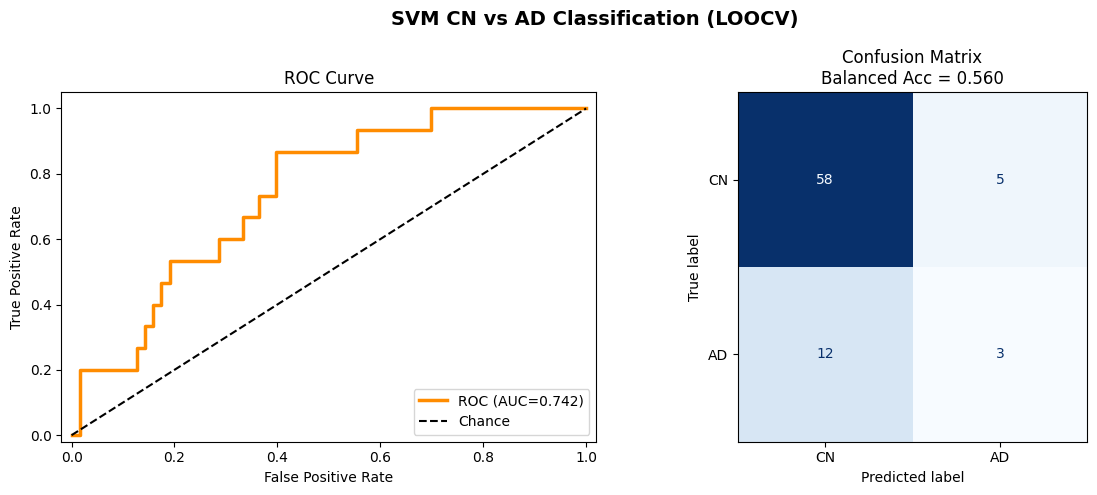

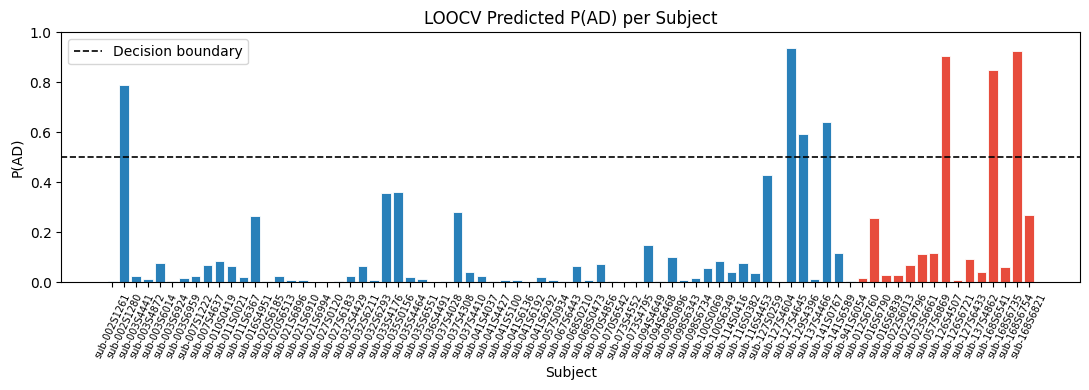


Saved combined figure -> /content/drive/MyDrive/fmri_project/outputs/SVRSVM/outputs/svm_loocv_results.png
Saved probability plot -> /content/drive/MyDrive/fmri_project/outputs/SVRSVM/outputs/svm_loocv_prob_per_subject.png
Saved report card -> /content/drive/MyDrive/fmri_project/outputs/SVRSVM/outputs/svm_loocv_report_card.csv
Saved text report -> /content/drive/MyDrive/fmri_project/outputs/SVRSVM/outputs/svm_loocv_classification_report.txt

DONE


In [ ]:
# ============================================================
# Colab-ready SVM CN vs AD classification using FULL FC
# Honest LOOCV with fold-wise feature selection
# ============================================================

# If needed in a fresh Colab:
# !pip install -q numpy pandas scipy scikit-learn matplotlib

from google.colab import drive
drive.mount('/content/drive')

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/fmri_project"
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs/"
OUT_DIR = "/content/drive/MyDrive/fmri_project/outputs/SVRSVM/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

cn_path = os.path.join(DATA_DIR, "fmri_features_CN.npz")
ad_path = os.path.join(DATA_DIR, "fmri_features_AD.npz")
bag_path = os.path.join(DATA_DIR, "stage1_all_subjects_bag.csv")

for p in [cn_path, ad_path, bag_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")

# ============================================================
# 2. Load raw connectivity features
# ============================================================
fmri_cn = np.load(cn_path, allow_pickle=True)
fmri_ad = np.load(ad_path, allow_pickle=True)

cn_full = fmri_cn["FULL"].astype(np.float32)
ad_full = fmri_ad["FULL"].astype(np.float32)

X = np.vstack([cn_full, ad_full])
y = np.array([0] * len(cn_full) + [1] * len(ad_full), dtype=int)  # CN=0, AD=1

subjects = np.concatenate([
    fmri_cn["subjects"].astype(str),
    fmri_ad["subjects"].astype(str)
])

ages = np.concatenate([
    fmri_cn["ages"].astype(np.float32),
    fmri_ad["ages"].astype(np.float32)
])

dx_labels = np.array(["CN"] * len(cn_full) + ["AD"] * len(ad_full))

print("=" * 60)
print("SVM Classification: CN vs AD")
print("=" * 60)
print(f"Total subjects: {len(y)}")
print(f"CN subjects   : {(y == 0).sum()}")
print(f"AD subjects   : {(y == 1).sum()}")
print(f"Feature shape : {X.shape}")
print()

# ============================================================
# 3. Honest Leave-One-Out CV
#    All preprocessing happens inside each fold
# ============================================================
y_true_list = []
y_pred_list = []
y_prob_list = []
n_feat_list = []

print("Running LOOCV...")

for test_idx in range(len(y)):
    train_idx = np.array([i for i in range(len(y)) if i != test_idx])

    X_tr = X[train_idx]
    X_te = X[test_idx:test_idx + 1]
    y_tr = y[train_idx]

    cn_tr = X_tr[y_tr == 0]
    ad_tr = X_tr[y_tr == 1]

    # ------------------------------
    # a) Feature selection on train only
    # ------------------------------
    pvals = np.array([
        mannwhitneyu(cn_tr[:, j], ad_tr[:, j], alternative="two-sided").pvalue
        for j in range(X_tr.shape[1])
    ])

    mask = pvals < 0.05

    # fallback if too few selected
    if mask.sum() < 10:
        mask = np.zeros(X_tr.shape[1], dtype=bool)
        top_k = min(50, X_tr.shape[1])
        mask[np.argsort(pvals)[:top_k]] = True

    X_tr_sel = X_tr[:, mask]
    X_te_sel = X_te[:, mask]
    n_feat_list.append(mask.sum())

    # ------------------------------
    # b) Scale on train only
    # ------------------------------
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_sel)
    X_te_sc = scaler.transform(X_te_sel)

    # ------------------------------
    # c) PCA on train only
    # ------------------------------
    n_comp = min(5, X_tr_sc.shape[0] - 1, X_tr_sc.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    X_tr_pc = pca.fit_transform(X_tr_sc)
    X_te_pc = pca.transform(X_te_sc)

    # ------------------------------
    # d) SVM
    # ------------------------------
    clf = SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        random_state=42
    )
    clf.fit(X_tr_pc, y_tr)

    pred = clf.predict(X_te_pc)[0]
    prob = clf.predict_proba(X_te_pc)[0, 1]

    y_true_list.append(y[test_idx])
    y_pred_list.append(pred)
    y_prob_list.append(prob)

    status = "OK" if pred == y[test_idx] else "XX"
    print(
        f"[{status}] {subjects[test_idx]:20s} | "
        f"true={dx_labels[test_idx]:2s} pred={'AD' if pred else 'CN':2s} | "
        f"P(AD)={prob:.3f} | features={mask.sum()}"
    )

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

# ============================================================
# 4. Metrics
# ============================================================
print("\n" + "=" * 60)
print("LOOCV Classification Report")
print("=" * 60)

report = classification_report(y_true, y_pred, target_names=["CN", "AD"], digits=4)
print(report)

cm = confusion_matrix(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)
roc_auc_val = roc_auc_score(y_true, y_prob)

print("Confusion Matrix:")
print(cm)
print(f"\nBalanced Accuracy : {bacc:.4f}")
print(f"ROC-AUC           : {roc_auc_val:.4f}")
print(f"Avg features/fold : {np.mean(n_feat_list):.1f}")

# ============================================================
# 5. Per-subject report card
# ============================================================
bag_df = pd.read_csv(bag_path)

report_df = pd.DataFrame({
    "subject": subjects,
    "age": ages,
    "DX_true": dx_labels,
    "DX_pred": np.where(y_pred == 1, "AD", "CN"),
    "P_AD": np.round(y_prob, 4),
    "correct": (y_true == y_pred)
})

report_df = report_df.merge(
    bag_df[["subject", "BAG_full", "BAG_left", "BAG_right", "BAG_inter"]],
    on="subject",
    how="left"
)

print("\nPer-subject report card:")
print(report_df.to_string(index=False))

# ============================================================
# 6. Plots
# ============================================================
# ROC + confusion matrix
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc_plot = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("SVM CN vs AD Classification (LOOCV)", fontsize=14, fontweight="bold")

ax_roc = axes[0]
ax_roc.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC (AUC={roc_auc_plot:.3f})")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1.5, label="Chance")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve")
ax_roc.legend(loc="lower right")
ax_roc.set_xlim([-0.02, 1.02])
ax_roc.set_ylim([-0.02, 1.05])

ax_cm = axes[1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["CN", "AD"])
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title(f"Confusion Matrix\nBalanced Acc = {bacc:.3f}")

plt.tight_layout()
plt.show()

fig_path = os.path.join(OUT_DIR, "svm_loocv_results.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.close(fig)

# Per-subject P(AD)
fig2, ax2 = plt.subplots(figsize=(11, 4))
colors = ["#e74c3c" if dx == "AD" else "#2980b9" for dx in dx_labels]

ax2.bar(subjects, y_prob, color=colors, edgecolor="white", linewidth=0.6)
ax2.axhline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision boundary")
ax2.set_xlabel("Subject")
ax2.set_ylabel("P(AD)")
ax2.set_title("LOOCV Predicted P(AD) per Subject")
ax2.set_ylim(0, 1)
ax2.tick_params(axis="x", rotation=65, labelsize=7)
ax2.legend()
plt.tight_layout()
plt.show()

prob_fig_path = os.path.join(OUT_DIR, "svm_loocv_prob_per_subject.png")
fig2.savefig(prob_fig_path, dpi=150, bbox_inches="tight")
plt.close(fig2)

print(f"\nSaved combined figure -> {fig_path}")
print(f"Saved probability plot -> {prob_fig_path}")

# ============================================================
# 7. Save outputs
# ============================================================
report_card_path = os.path.join(OUT_DIR, "svm_loocv_report_card.csv")
report_df.to_csv(report_card_path, index=False)

clf_report_path = os.path.join(OUT_DIR, "svm_loocv_classification_report.txt")
with open(clf_report_path, "w") as f:
    f.write("SVM Classification Report (LOOCV, FULL connectivity)\n")
    f.write("=" * 60 + "\n")
    f.write(report)
    f.write(f"\nBalanced Accuracy : {bacc:.4f}\n")
    f.write(f"ROC-AUC           : {roc_auc_val:.4f}\n")
    f.write("\nConfusion Matrix (rows=true, cols=pred):\n")
    cm_df = pd.DataFrame(cm, index=["True CN", "True AD"], columns=["Pred CN", "Pred AD"])
    f.write(cm_df.to_string() + "\n")

print(f"Saved report card -> {report_card_path}")
print(f"Saved text report -> {clf_report_path}")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

### person report

In [ ]:
import os
import pandas as pd

OUT_DIR = "/content/drive/MyDrive/fmri_project/outputs"

bag_df = pd.read_csv(os.path.join(OUT_DIR, "stage1_all_subjects_bag.csv"))
svm_df = pd.read_csv(os.path.join(OUT_DIR, "svm_loocv_report_card.csv"))

report_df = bag_df.merge(svm_df[["subject", "DX_pred", "P_AD"]], on="subject", how="left")

report_df["brain_age_profile"] = (
    "Full BAG=" + report_df["BAG_full"].round(2).astype(str) +
    "; Left=" + report_df["BAG_left"].round(2).astype(str) +
    "; Right=" + report_df["BAG_right"].round(2).astype(str) +
    "; Inter=" + report_df["BAG_inter"].round(2).astype(str)
)

report_df.to_csv(os.path.join(OUT_DIR, "subject_report_card.csv"), index=False)
print("Saved:", os.path.join(OUT_DIR, "subject_report_card.csv"))

print(report_df.head())

Saved: /content/drive/MyDrive/fmri_project/outputs/subject_report_card.csv
        subject   age  DX  mmse  pred_age_full  BAG_full  pred_age_left  \
0  sub-002S1261  71.1  CN  30.0      71.200619  0.100621      71.200005   
1  sub-002S1280  70.7  CN  30.0      70.799733  0.099736      70.799713   
2  sub-003S4441  68.7  CN  28.0      70.760061  2.060064      70.511623   
3  sub-003S4872  68.5  CN  28.0      70.787236  2.287236      70.852489   
4  sub-003S6014  67.1  CN  30.0      70.871484  3.771486      71.111056   

   BAG_left  pred_age_right  BAG_right  pred_age_inter  BAG_inter DX_pred  \
0  0.100006       70.599931  -0.500067       71.008352  -0.091647      CN   
1  0.099716       71.200240   0.500243       70.799953   0.099956      AD   
2  1.811626       71.096265   2.396268       70.086772   1.386775      CN   
3  2.352489       70.981720   2.481720       70.691649   2.191649      CN   
4  4.011057       70.871596   3.771597       70.844678   3.744679      CN   

     P_AD  

In [ ]:
bag_df = pd.read_csv(bag_path)
print(bag_df.tail(20))
print(bag_df["DX"].value_counts(dropna=False))

         subject   age   DX  mmse  pred_age_full  BAG_full  pred_age_left  \
43  sub-073S4552  63.2   CN  30.0      70.789165  7.589164      70.945663   
44  sub-073S4795  61.2   CN  29.0      70.761377  9.561376      70.823769   
45  sub-094S4649  65.4   CN  30.0      70.784422  5.384421      70.830412   
46  sub-094S6468  69.4   CN  29.0      70.813272  1.413270      70.870101   
47  sub-098S0896  76.8   CN  30.0      72.632211 -4.167792      72.876281   
48  sub-098S6343  67.0   CN  30.0      71.094486  4.094486      70.852746   
49  sub-098S6734  73.2  NaN  29.0      71.346920 -1.853077      71.503458   
50  sub-100S0069  72.9   CN  28.0      72.787236 -0.112765      72.800098   
51  sub-100S6349  73.8   CN  30.0      72.744491 -1.055512      72.851967   
52  sub-114S0416  75.6   CN  29.0      73.008160 -2.591838      72.776296   
53  sub-116S0382  75.5   CN  29.0      72.638158 -2.861842      72.720491   
54  sub-116S4453  65.9   CN  29.0      70.826258  4.926257      70.572812   

In [ ]:
threshold = 0.4
y_pred_thresh = (y_prob >= threshold).astype(int)

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_true, y_pred_thresh)
prec = precision_score(y_true, y_pred_thresh)
rec = recall_score(y_true, y_pred_thresh)
f1 = f1_score(y_true, y_pred_thresh)

print("Threshold:", threshold)
print("Confusion matrix:\n", cm)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

Threshold: 0.4
Confusion matrix:
 [[58  5]
 [12  3]]
Precision: 0.375
Recall: 0.2
F1: 0.2608695652173913


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

Best threshold: 0.028083913901619156
